### Análise Estatística de Dados com NumPy Para a Área de Marketing

1. Uma plataforma de e-commerce coleta um volume significativo de dados sobre a interação do usuários com o site, incluíndo o número de visitas, a duração da sessão, a atividade de adição de produtos ao carrinho e os valores de compra finalizados. No entanto, esses dados estão sempre subutilizados. Atualmente, as decisões sobre campanhas de marketing, promoções e molhorias na experiência do usuário (UX) são tomadas com base em intuições e métricas de alto nível, sem uma compreensão profunda dos dados de comportamento que impulsionam os resultados.

1.2. Problema de Negócio

A empresa enfrenta o desafio de compreender profundamente os padrões de comportamento que diferenciam os clientes de alto valor dos visitantes que abandonam o site sem comprar. Essa felta de clareza resulta em:

 - Marketing Genérico: Nossas campanhas de marketing são de tamanho único, resultando em baixo engajamento e desperdício de orçamento, pois não personalizar as ofertaspara os segmentos de clientes corretos.

 - Perda de oportunidads: Não conseguimos identificar e engajar proativamente os cliente com maior potencial de compra ou criar estratégias para converter os visitantes que demonstram interesse, mas não finalizam a compra.

 - Decisões não embasadas: As estratégias de produto e de experiência do usuário carecem uma base quantitativa sólida sobre quais comportamentos (ex: tempo no site, frequência de visitas) estão mais fortemente correlacionados com o sucesso das vendas.

1.3. Objetivo Principal

Utilizar a análise estatística dos dados de navegação e compra para segmentar clientes, identificar os principais indicadores de comportamento que levem à conversão e fornecer insights acionáveis para a equipe de marketing e produtos, a fim de aumentar o ticket médio
e a taxa de conversão geral da plataforma.

1.4. Perguntas-chave a serem respondidas

A análise de dados deve responder as seguintes perguntas críticas de negócio:

  - 1 - Qual é o perfil médio do nosso usuário em termos de visitas, tempo de navegação e valor de compra (ticket médio)
    
  - 2 - Quais são as características e comportamentos distintos dos nossos clientes de alto valor? Eles visitam mais o site? Passam mais tempo navegando?

    
  - 3 - Qual o comportamento dos usuários que visitam o site, mas não realizam nenhuma compra? Onde está a oportunidade de conversão com este grupo?

    
  - 4 - Existe um correlação estatísticamente relevante entre o tempo gasto no site, o número de itens no carrinho e o valor final da compra?

1.5. Resultado esperado e impacto do negócio

O resultado deste projeto será um relatório de análise estatística que permitirá:

  - Segmentação aprimorada: Criação de pelo menos dois segmentos de clientes (Ex: "Cliente de alto valor" e "Visitantes engajados sem compra") para direcionamento de companhas de marketing personalizadas.

  - Otimização de marketing: Direcionar o orçamento de marketing para ações nos comportamentos que mais re correlacionam com compra de alto valor, aumentando o retorno sobre o investimento (ROI).

  - Melhoria da experincia de usuário (ux): Fornecer à equipe de produto dados que possam justificar testes a/b ou melhorias em área do site frequentadas por usuários que não convertem.

In [1]:
!pip install -q -U watermark

In [2]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [6]:
# Definir uma semente para reprodutibilidade dos resultados
np.random.seed(42)

In [7]:
%reload_ext watermark
%watermark -a "Leonardo da Silva Neves"

Author: Leonardo da Silva Neves



In [8]:
%watermark --iversion

matplotlib: 3.10.8
numpy     : 2.3.5
pandas    : 2.3.3



**3. Função para gerar dados fictícios**

Vamos criar um conjunto de dados para quinhentos usuários. Cada usuário terá quatro métricas associadas descritas abaixo.

 - visitas: Número de vezes que o usuário visitou o site no mês.
 - tempo_no_site: Tempo total em minutos que o usuário passou no site.
 - itens_no_carinho: Número de itens que o usuário adicionou ao carrinho.
 - valor_compra: O valor total em R$ da compra realizada pelo usuário no mês.

In [9]:
# Definir o número de usuários
num_usuarios = 500

In [10]:
# 1. Gerar o número de visitas entre 1 e 50
visitas = np.random.randint(1, 51, size = num_usuarios)

**Distribuição Normal**

A distribuição normal é um tipo de distribuição de probabilidade contínua, simétrica em torno da média, com formato característico de sino. Nesse tipo de distribuição os valores próximos da média são mais frequêntes e a probabilidade de observar valores extremos diminui gradualmente conforme se afasta do centro. É definida por dois parâmetros: a média (que indica o centro da distribuição) e o desvio padrâo (que indica a dispersão dos dados). É muito usado em estatística e ciência dos dados porque muitos fenômenos naturais e sociais tendem a seguir esse padrão.

In [11]:
# 2. Gerar o tempo do site (distribuição normal, correlacionando com as visitas)
# Média de 20 minutos, desvio padrão de 5, com bônus por visita
tempo_no_site = np.random.normal(loc=20, scale=5, size = num_usuarios) + (visitas * 0.5)
tempo_no_site = np.round(tempo_no_site, 2) # Arredondar para 2 casas decimais

In [12]:
# 3. Gerar número de itens no carrinho (dependente das visitas e do tempo))
# Usuários que visitam mais e passam mais tempo, tendem a adicionar mais itens
itens_no_carrinho = np.random.randint(0, 8, size = num_usuarios) + (visitas // 10)

In [13]:
# Garante que o tempo no site também influencie positivamente
itens_no_carrinho = (itens_no_carrinho + (tempo_no_site // 15)).astype(int)

In [14]:
# 4. Gerar o valor da compra (correlacionado com os itens no carrinho)
# Preço médio por item de R$ 35, com alguma variação aleatória
valor_compra = (itens_no_carrinho * 35) + np.random.normal(loc = 0, scale = 10, size = num_usuarios)

In [15]:
# Se não houver item no carrinho, o valor deve ser zero
valor_compra[itens_no_carrinho == 0] = 0
valor_compra[valor_compra < 0] = 0 # Corrigir valor negativo que possam surgir
valor_compra = np.round(valor_compra, 2)

In [16]:
# Unindo tudo em uma únicac matriz (ndarray)
# Cada linha representa um número, cada coluna uma métrica
dados_ecommerce = np.column_stack((visitas, tempo_no_site, itens_no_carrinho, valor_compra))

In [17]:
print("\nShape da massa de dados:", dados_ecommerce.shape)
print("\nExemplos dos 5 primeiros usuários (linhas:")
print("\nColunas: [Visitas, Tempo no Site (min), Itens no Carrinho, Valor da Compra (R$)]\n")
print(dados_ecommerce[:5])


Shape da massa de dados: (500, 4)

Exemplos dos 5 primeiros usuários (linhas:

Colunas: [Visitas, Tempo no Site (min), Itens no Carrinho, Valor da Compra (R$)]

[[ 39.    23.29   9.   314.54]
 [ 29.    29.38   5.   177.43]
 [ 15.    26.24   6.   207.59]
 [ 43.    35.26   8.   283.52]
 [  8.    32.16   3.    92.48]]


**4. Análise Estatística Descritiva**

Agora que temos os dados, vamos calcular as principais métricas estatísticas para cada coluna para tem uma visão geral do comportamento dos nossos usuários.

 - A média é a soma de todas os valores dividido pela quantidade de elementos. Ela indica o valor "central" ou típico de um conjuto de dados.
 - A mediana é o valor que fica exatamente no meio quando os valores estão ordenados. Se houver número par de valores, é a média dos dois valores centrais. Ela é menos sensível a valores extremos do que a média.
 - O desvio padrão mede o quanto os valores se afastam, em média, da média do conjunto. Um desvio padrão alto significa qua os dados são mais mais espalhados; um baixo indica que estão mais próximos da média.

**Pergunta 1**

Qual é o pergil médio do nosso usuário em termos de visita, tempo de navegação e valor de compra (ticket médio)?

In [18]:
# Separar as colunas para facilitar a leitura do código
visitas_col = dados_ecommerce[:,0]
tempo_col = dados_ecommerce[:,1]
itens_col = dados_ecommerce[:,2]
valor_col = dados_ecommerce[:,3]

print("--- ANÁLISE ESTATÍSTICA GERAL ---")

# Média

media_visitas = np.mean(visitas_col)
media_tempo = np.mean(tempo_col)
media_itens = np.mean(itens_col)
media_valor = np.mean(valor_col)

print(f"\nMédia de visitas: {media_visitas:.2f}")
print(f"Média de Tempo no Site: {media_tempo:.2f} min")
print(f"Média de Itens no Carrinho: {media_itens:.2f}")
print(f"Média de Valor de Compra (Ticket Médio): R$ {media_valor:.2f}")

# Mediana (valor central, menos sensível a outliers)
mediana_valor = np.median(valor_col)
print(f"\nMediana do Valor de Compra: R$ {mediana_valor:.2f}")

# Desvio Padrão (mede a dispersão dos dados)
std_valor = np.std(valor_col)
print(f"Desvio Padrão do Valor de Compra: R$ {std_valor:.2f}")

# Valor Máximo e Mínimos
max_valor = np.max(valor_col)
min_valor_positivo = np.min(valor_col[valor_col > 0]) # Mínimo apenas entre quem comprou
print(f"Maior Valor de Compra: R$ {max_valor:.2f}")
print(f"Menor Valor de Compra (de quem comprou): R$ {min_valor_positivo:.2f}")

--- ANÁLISE ESTATÍSTICA GERAL ---

Média de visitas: 25.86
Média de Tempo no Site: 32.78 min
Média de Itens no Carrinho: 7.20
Média de Valor de Compra (Ticket Médio): R$ 252.70

Mediana do Valor de Compra: R$ 248.13
Desvio Padrão do Valor de Compra: R$ 106.94
Maior Valor de Compra: R$ 530.37
Menor Valor de Compra (de quem comprou): R$ 23.42


O gráfico abaixo mostra o histograma dos valores de compra com linhas verticais indicando a média (vermelho), a mediana(laranja) e o intervalo de um desvio padrão acima e abaixo da média (linhas verdes). Isso facilia análise de como os dados estão distribuídos e se existem possiveiis outliers ou assimetrias.

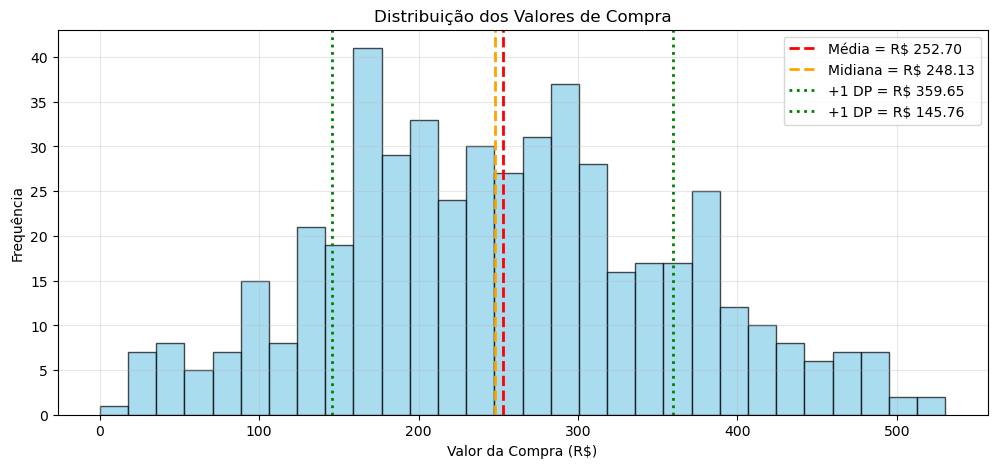

In [19]:
# Separando colunas

visitas_col = dados_ecommerce[:,0]
tempo_col = dados_ecommerce[:,1]
itens_col = dados_ecommerce[:,2]
valor_col = dados_ecommerce[:,3]

# Calculando as Estatísticas
media_valor = np.mean(valor_col)
mediana_valor = np.median(valor_col)
std_valor = np.std(valor_col)

# --- Gráfico ---
plt.figure(figsize=(12,5))
plt.hist(valor_col, bins=30, color= 'skyblue', edgecolor = 'black', alpha = 0.7)
plt.axvline(media_valor, color = 'red', linestyle = '--', linewidth = 2, label = f'Média = R$ {media_valor:.2f}')
plt.axvline(mediana_valor, color = 'orange', linestyle = '--', linewidth = 2, label = f'Midiana = R$ {mediana_valor:.2f}')
plt.axvline(media_valor + std_valor, color = 'green', linestyle = ':', linewidth = 2, label = f'+1 DP = R$ {media_valor + std_valor:.2f}')
plt.axvline(media_valor - std_valor, color = 'green', linestyle = ':', linewidth = 2, label = f'+1 DP = R$ {media_valor - std_valor:.2f}')
plt.title("Distribuição dos Valores de Compra")
plt.xlabel("Valor da Compra (R$)")
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

**Resposta da pergunta 1:**

O usuário acessa o site, em média, cerca de 26 vezes por mês, permanece em média 33 minutos navegando, adiciona aproximadamente 7 ao carrinho e realiza compras com ticket médio de R$ 252,70.

O gasto típico fica próximo da mediana de R$ 248,13.

Mas há grande variação entre clientes, alguns compram valores baixo a partir de R$ 23,42

Enquando outro chegam a gastar até 530,37

**5. Segmentação e Análise de Clientes**

Quais são as características se comportamentos distintos dos nossos clientes de "Alto-valor"? Eles visitam mais o site? Passam mais tempo navegando?

In [23]:
# Filtro booleano para clientes com compra > R$250
clientes_alto_valor = dados_ecommerce[dados_ecommerce[:,3] > 250]

print("\n--- ANÁLISE: CLIENTES DE ALTO VALOR (Compra > R$250) ---\n")
print(f"Número de clientes de alto valor: {clientes_alto_valor.shape[0]}")

# Estatísticas deste segmento
media_visitas_alto_valor = np.mean(cliente_alto_valor[:,0])
media_tempo_alto_valor = np.mean(cliente_alto_valor[:,1])

print(f"Média de visitas desses clientes: {media_visitas_alto_valor:.2f}")
print(f"Média de tempo no site desses cliente: {media_tempo_alto_valor:.2f}")


--- ANÁLISE: CLIENTES DE ALTO VALOR (Compra > R$250) ---

Número de clientes de alto valor: 245
Média de visitas desses clientes: 33.29
Média de tempo no site desses cliente: 37.11


**Resposta da Pergunta 2**

Os clientes de alto valor (aqueles que gastam mais de R$250) visitam o site com mair frequência, em média 33 vezes por mês, e permanecem mais tempo navegando, cerca de 37 minutos por sessão. Esse comportamento indica um alto nível de engajamento, sugerindo que quanto mais esses usuários interagem com a plataforma, maior tende a ser o valor de suas compras.

**Pergunta 3**

Qual o comportamento dos usuários que visitam o site, mas não realizam nenhuma compra? Onde está a oportunidade de conversão com este grupo?

In [26]:
# Filtro para visitantes que não compram
visitantes_sem_compra = dados_ecommerce[dados_ecommerce[:,3] == 0]

print("\n--- ANÁLISE: VISITANTES QUE NÃO COMPRAM ---\n")
print(f"Número de visitantes que não compraram: {visitantes_sem_compra.shape[0]}")

# Estatística deste segmento
media_tempo_sem_compra = np.mean(visitantes_sem_compra[:,1])
media_visitas_sem_compra = np.mean(visitantes_sem_compra[:,0])

print(f"Média de visita desses visitantes: {media_visitas_sem_compra:.2f}")
print(f"Apesar de não comprarem, eles passam em média {media_tempo_sem_compra:.2f}")


--- ANÁLISE: VISITANTES QUE NÃO COMPRAM ---

Número de visitantes que não compraram: 1
Média de visita desses visitantes: 7.00
Apesar de não comprarem, eles passam em média 14.71


**Resposta da pergunta 3**

Os usuário que não realizam compras visitam o site em média 7 vezes e permanecem cerca de 15 minutos navegando, mas não finalizam nenhuma transação. Esse comportamento mostra que, mesmo com algum nível de interesse, eles acabam desistindo antes da compra, representando uma oportunidade para ações de remarketing, otimização do checkout e estratégias de incentivo, como descontos ou frete grátis, para aumentar a conversão.

**Análise de Correlação**

Vamos investigar a relação entre as diferentes variáveis. Uma matriz de correlação nos mostra como as veriáveis se movem juntas.

 - +1: Correlação positiva perfeita
 - -1: Correlação negativa perfeita
 - 0: nenhuma correlação linear

**Pergunta 4**

Existe uma correlação estatisticamente relavante entre o tempo gasto no site, o número de itens no carrinho e o valor final da compra?